          Task 1.1: logistic classification using stratifieed sampling
+++++++++++++++++++++++++++++++++++++++++++++
      assessing and choosing 4 feautres using correlation
+++++++++++++++++++++++++++++++++++++++++++++
Feautre/living correlation:
rows_with_2        0.2176
hollowness         0.2113
connected_areas    0.2107
cols_with_2        0.1960
cols_with_1        0.1382
aspect_ratio       0.0685
width             -0.0000
rows_with_3p      -0.0000
height            -0.0269
img_bdensity      -0.1485
cols_with_3p      -0.1961
nr_pix            -0.2581
maxcol            -0.2915
maxrow            -0.3445
rows_with_1       -0.3479
eyes              -0.3900
---------------------------------------------
Top 4 correlated features(they will be used in the models):
eyes
rows_with_1
maxrow
maxcol
+++++++++++++++++++++++++++++++++++++++++++++
      logistic classification metrics
+++++++++++++++++++++++++++++++++++++++++++++
                      Confusion Matrix
              Pred Living  Pr

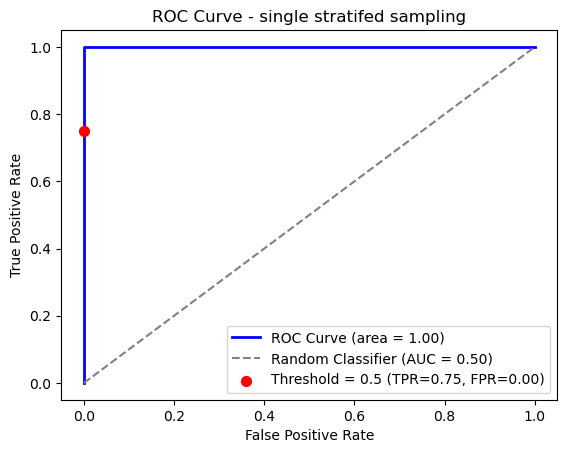

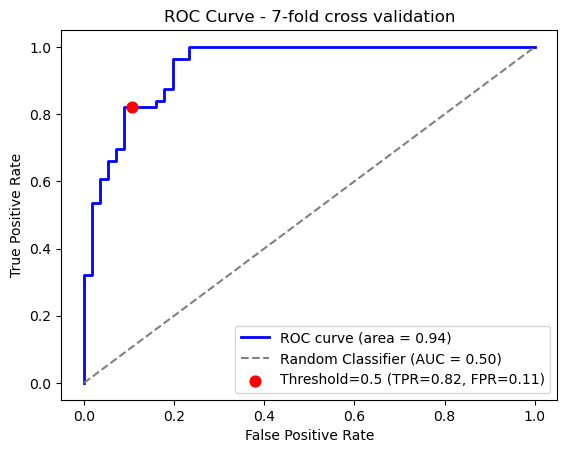

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np    
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                              roc_curve, auc)
from sklearn.model_selection import StratifiedKFold, cross_val_score


def main():

    src = "C:\\Users\\ammar\\Desktop\\A1_Ammar_Jileidan\\features.csv"
    df = pd.read_csv(src)
#========================================================================================================
    #Task 1.1
#========================================================================================================
    print("          Task 1.1: logistic classification using stratifieed sampling")
    print("+"*45)
    print("      assessing and choosing 4 feautres using correlation")
    print("+"*45)
    #create a variriable for object's type living(1) vs non-livivng(0)
    living = ["cherry", "banana", "lemon", "tree"]
    df["type"] = np.where(df["label"].isin(living), 1, 0)

    #//////////////////////////////////////////////////////////////////////////////////////////////
    #assessing correlation between feautres and type to identify the most usefual 4 feautres
    correlation = df[['nr_pix', 'rows_with_1', 'cols_with_1', 'rows_with_2',
                   'cols_with_2', 'rows_with_3p', 'cols_with_3p', 'height',
                   'width', 'aspect_ratio', 'maxrow', 'maxcol',
                   'connected_areas', 'eyes', 'hollowness',
                   'img_bdensity']].corrwith(df['type'])
    print("Feautre/living correlation:")
    print(correlation.sort_values(ascending=False).round(4).to_string())
    print("-"*45)
    top4 = correlation.abs().sort_values(ascending=False).head(4).index

    print("Top 4 correlated features(they will be used in the models):")
    for f in top4:
        print(f)
    #//////////////////////////////////////////////////////////////////////////////////////////////
    #spliting the population for training and test
    train_list = []
    test_list  = []
    for class_name, group in df.groupby('label'):
        test_sample  = group.sample(n=3, random_state=42)
        train_sample = group.drop(test_sample.index)

        test_list.append(test_sample)
        train_list.append(train_sample)

    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df  = pd.concat(test_list).reset_index(drop=True)

    #//////////////////////////////////////////////////////////////////////////////////////////////
    #the chosen feautres
    FEATURES = ['eyes', 'rows_with_1', 'maxrow', 'maxcol']
    
    # Extract the chosen features and class
    X_train = train_df[FEATURES].values
    y_train = train_df['type'].values
    
    X_test  = test_df[FEATURES].values
    y_test  = test_df['type'].values
    
    # Standardise
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    #//////////////////////////////////////////////////////////////////////////////////////////////
    # Fit the model
    model = LogisticRegression()
    model.fit(X_train_sc, y_train)

    # test the model
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    
    #//////////////////////////////////////////////////////////////////////////////////////////////
    #                     metrics 
    # Confusion Matrix
    print("+"*45)
    print("      logistic classification metrics")
    print("+"*45)
    
    TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
    print("                      Confusion Matrix")
    print("              Pred Living  Pred Nonliving")
    print(f"Actual Living      {TP}             {FN}")
    print(f"Actual Nonliving   {FP}             {TN}")
    print("-"*30)

    #  false positive rate
    FPR       = FP / (FP + TN)
    print(f"False Positive Rate  : {FPR:.4f}")
    print("-"*30)
    
    # accuracy
    accuracy  = accuracy_score(y_test, y_pred)
    print(f"Accuracy             : {accuracy:.4f}")
    print("-"*30)
    #precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision            : {precision:.4f}")
    print("-"*30)
    #recall/TPR
    recall    = recall_score(y_test, y_pred)
    print(f"Recall/TPR           : {recall:.4f}")
    print("-"*30)
    #F1 score
    f1        = f1_score(y_test, y_pred)
    print(f"F1-Score             : {f1:.4f}")

    print("-"*30)
    print("")

    

#========================================================================================================
    #Task 1.2
#========================================================================================================
    print("="*55)
    print("      Task 1.2: useing 7-fold Cross validation")
    print("="*55)
    print("")
    print("+"*45)
    print("      Avarge metrics over the 7 folds")
    print("+"*45)


    skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
    
    # Store metrics for each fold
    fold_results = []
    #for Task 1.3
    all_y_true = []
    all_y_prob = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(df, df['label'])):
        
        #assign the folds
        train_fold = df.iloc[train_idx]
        test_fold  = df.iloc[test_idx]
        
        # Extract features 
        X_train_fold = train_fold[FEATURES].values
        X_test_fold  = test_fold[FEATURES].values
        y_train_fold = train_fold['type'].values
        y_test_fold  = test_fold['type'].values
        
        # Standardise 
        scaler_fold     = StandardScaler()
        X_train_fold_sc = scaler_fold.fit_transform(X_train_fold)
        X_test_fold_sc  = scaler_fold.transform(X_test_fold)
    
        # Fit model
        model_fold = LogisticRegression()
        model_fold.fit(X_train_fold_sc, y_train_fold)
        
        # Predict
        y_pred_fold = model_fold.predict(X_test_fold_sc)
        y_prob_fold = model_fold.predict_proba(X_test_fold_sc)[:, 1]
        
        # save metrics
        TNF, FPF, FNF, TPF = confusion_matrix(y_test_fold, y_pred_fold).ravel()
        fold_results.append({
            'Accuracy' : accuracy_score(y_test_fold, y_pred_fold),
            'TPR'      : recall_score(y_test_fold, y_pred_fold),
            'FPR'      : FPF / (FPF + TNF) if (FPF + TNF) > 0 else 0,
            'Precision': precision_score(y_test_fold, y_pred_fold),
            'F1'       : f1_score(y_test_fold, y_pred_fold),
        })
        
        # Collect for The ROC curve task 1.3
        all_y_true.extend(y_test_fold)
        all_y_prob.extend(y_prob_fold)
        
    # Average metrics across all 7 folds
    results_df = pd.DataFrame(fold_results)

    # Convert to arrays task 1.3
    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)
    

    print(f"Accuracy  : {results_df['Accuracy'].mean():.4f}")
    print("-"*45)
    print(f"TPR/Recall: {results_df['TPR'].mean():.4f}")
    print("-"*45)
    print(f"FPR       : {results_df['FPR'].mean():.4f}")
    print("-"*45)
    print(f"Precision : {results_df['Precision'].mean():.4f}")
    print("-"*45)
    print(f"F1        : {results_df['F1'].mean():.4f}")
    print("-"*45)

#========================================================================================================
    #Task 1.3
#========================================================================================================
        
        
    print("="*55)
    print("      TASK 1.3: ROC curve")
    print("="*55)
    
    # curve 1: for the first model
    # Compute ROC
    fpr_roc, tpr_roc, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_roc, tpr_roc)

    plt.figure()
    
    # ROC curve
    plt.plot(fpr_roc, tpr_roc, color='blue', lw=2,
             label=f'ROC Curve (area = {roc_auc:.2f})')
    
    # Random classifier line 
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Random Classifier (AUC = 0.50)')
    # Decision threshold point
    plt.scatter(FPR, recall, color='red', s=50, zorder=5,
                label=f'Threshold = 0.5 (TPR={recall:.2f}, FPR={FPR:.2f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - single stratifed sampling')
    plt.legend(loc='lower right')
    plt.show()


    #/////////////////////////////////////////////////////////////
    #Curve 2 for 7-Fold Cross Validation

    # Compute ROC
    fpr_cv, tpr_cv, thresholds_cv = roc_curve(all_y_true, all_y_prob)
    roc_auc_cv = auc(fpr_cv, tpr_cv)
    mean_fpr_point = np.mean([r['FPR'] for r in fold_results])
    mean_tpr_point = np.mean([r['TPR'] for r in fold_results])
    
    plt.figure()
    # ROC curve
    plt.plot(fpr_cv, tpr_cv, color='blue', lw=2,
             label=f'ROC curve (area = {roc_auc_cv:.2f})')
    # Random classifier line 
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Random Classifier (AUC = 0.50)')
    # Decision threshold point
    plt.scatter(mean_fpr_point, mean_tpr_point, color='red', s=60, zorder=5,
            label=f"Threshold=0.5 (TPR={mean_tpr_point:.2f}, FPR={mean_fpr_point:.2f})")
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - 7-fold cross validation')
    plt.legend(loc='lower right')
    plt.show()
    
main()
  
